# PD Calibration
## Layer 2 — 예측 확률을 신뢰 가능한 확률값으로 보정

## 목적

`03_modeling.ipynb`에서 선정한 최종 모델은 XGBoost(결측 NaN 유지, Optuna 100회 튜닝)로, AUC 0.7689 / KS 0.3969를 기록했습니다. 하지만 AUC와 KS는 위험 고객과 안전 고객을 얼마나 잘 구분하는지를 보여줄 뿐, 모델이 출력하는 확률값이 실제 부도율과 일치하는지는 보장하지 않습니다. 또한 트리 기반 부스팅 모델은 확률을 0 또는 1에 가깝게 과도하게 밀어내는 경향이 있어, 보정되지 않은 PD를 사용하면 기대손실이 체계적으로 과대 또는 과소평가될 수 있습니다. 따라서 본 노트북에서는 모델의 분류 성능뿐 아니라 예측 확률과 실제 부도율의 일치도를 calibration 관점에서 점검하고, 필요 시 보정을 수행합니다.

이 노트북에서는 다음 순서로 검증합니다.

1. 예측 확률이 실제 부도율과 얼마나 일치하는지 calibration 관점에서 점검
2. Reliability Diagram과 ECE를 통해 원시 확률의 보정 정도 확인
3. Platt Scaling과 Isotonic Regression을 비교해 보정 방식 선정
4. 보정 후에도 AUC와 KS가 유지되는지 확인해 순위 분리력 검증
5. 최종 방식 선정 및 `06_monitoring.ipynb` / `05_policy_simulation.ipynb`에서 쓸 산출물 저장

## Step 1. 최종 모델 재현

In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')

numeric_features = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'FLAG_EXT_SOURCE_MISSING',
    'AGE', 'EMPLOYMENT_YEARS', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
    'DTI', 'CIR', 'LTV', 'REPAYMENT_MONTHS',
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
    'PAYMENT_RATIO', 'LATE_PAYMENT_COUNT', 'LATE_DAYS_AVG',
    'BUREAU_ACTIVE_COUNT', 'BUREAU_OVERDUE_COUNT', 'BUREAU_LOAN_COUNT', 'BUREAU_BAD_COUNT',
    'PREV_REJECTED_COUNT', 'PREV_APPROVED_COUNT', 'PREV_REFUSAL_RATE',
]
cat_features = [
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'ORGANIZATION_TYPE', 'OCCUPATION_TYPE',
    'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'NAME_CONTRACT_TYPE',
]
all_features = numeric_features + cat_features

train_raw = pd.read_csv('../data/train_raw.csv')
val_raw   = pd.read_csv('../data/val_raw.csv')

binary_map = {'Y': 1, 'N': 0}
for df in [train_raw, val_raw]:
    df['FLAG_OWN_CAR']    = df['FLAG_OWN_CAR'].map(binary_map)
    df['FLAG_OWN_REALTY'] = df['FLAG_OWN_REALTY'].map(binary_map)
    for col in cat_features:
        df[col] = df[col].astype('category')

neg_pos_ratio = (train_raw['TARGET'] == 0).sum() / (train_raw['TARGET'] == 1).sum()

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
train_x, val_x = train_raw.copy(), val_raw.copy()
train_x[cat_features] = oe.fit_transform(train_x[cat_features].astype(str))
val_x[cat_features]   = oe.transform(val_x[cat_features].astype(str))

best_params = {
    'objective': 'binary:logistic', 'eval_metric': 'auc', 'tree_method': 'hist',
    'random_state': 42, 'verbosity': 0, 'scale_pos_weight': neg_pos_ratio,
    'learning_rate': 0.044206955225435066,
    'max_depth': 4,
    'min_child_weight': 38,
    'subsample': 0.9006856798274031,
    'colsample_bytree': 0.5766701071296396,
    'reg_alpha': 0.0004913590791351658,
    'reg_lambda': 0.009018464273654977,
    'gamma': 0.15464838089851346,
}

dtrain = xgb.DMatrix(train_x[all_features], label=train_raw['TARGET'])
dval   = xgb.DMatrix(val_x[all_features],   label=val_raw['TARGET'])

xgb_model = xgb.train(best_params, dtrain, num_boost_round=1000, evals=[(dval, 'val')],
                       early_stopping_rounds=50, verbose_eval=False)

val_prob_raw = xgb_model.predict(dval)
reproduced_auc = roc_auc_score(val_raw['TARGET'], val_prob_raw)
reproduced_ks, _ = ks_2samp(val_prob_raw[val_raw['TARGET'] == 1], val_prob_raw[val_raw['TARGET'] == 0])
print(f"재현 AUC: {reproduced_auc:.4f}  (03_modeling 기록값: 0.7689)")
print(f"재현 KS : {reproduced_ks:.4f}  (03_modeling 기록값: 0.3969)")


재현 AUC: 0.7689  (03_modeling 기록값: 0.7689)
재현 KS : 0.3969  (03_modeling 기록값: 0.3969)


## Step 2. Calibration용 홀드아웃 분리

`val_raw`는 Optuna 튜닝에서 모델 선택에 사용되었으므로, calibration 성능은 별도 홀드아웃에서 평가해 모델 선택과 평가의 이중 의존으로 인한 과적합 위험을 줄였습니다.

이를 피하기 위해 `val_raw`를 다시 두 개로 분리합니다.

- `calib_fit` (50%): Platt Scaling / Isotonic Regression을 적합하는 데만 사용
- `calib_eval` (50%): 두 방식의 calibration 성능(ECE)과 분리력(AUC) 변화를 실제로 비교·평가하는 데만 사용

TARGET 비율이 매우 낮은 불균형 데이터이므로 `stratify`로 부도 비율을 양쪽에 동일하게 유지합니다.


In [2]:
val_idx = np.arange(len(val_raw))
fit_idx, eval_idx = train_test_split(
    val_idx, test_size=0.5, stratify=val_raw['TARGET'], random_state=42
)

y_fit  = val_raw['TARGET'].values[fit_idx]
y_eval = val_raw['TARGET'].values[eval_idx]
prob_raw_fit  = val_prob_raw[fit_idx]
prob_raw_eval = val_prob_raw[eval_idx]

print(f"calib_fit  : {len(fit_idx):,}건 (부도율 {y_fit.mean():.4f})")
print(f"calib_eval : {len(eval_idx):,}건 (부도율 {y_eval.mean():.4f})")


calib_fit  : 30,751건 (부도율 0.0807)
calib_eval : 30,752건 (부도율 0.0807)


## Step 3. 보정 전 Calibration 상태 확인

보정에 앞서 원시 예측확률이 실제 부도율과 얼마나 일치하는지 Reliability Diagram과 ECE(Expected Calibration Error)를 먼저 확인합니다. 완벽하게 보정된 모델이라면 다이어그램에서 각 구간의 평균 예측 확률과 실제 부도율이 대각선에 가까워야 하고, ECE는 값이 작을수록 예측 확률이 실제 부도율에 더 가깝다는 의미입니다.

보정 전 ECE: 0.3112
    bin    n  confidence  actual_rate
0.0-0.1 1909    0.069473     0.009953
0.1-0.2 4949    0.151986     0.018185
0.2-0.3 5398    0.249882     0.032234
0.3-0.4 4874    0.349290     0.048625
0.4-0.5 4167    0.448787     0.075594
0.5-0.6 3498    0.548502     0.104631
0.6-0.7 2670    0.647358     0.139700
0.7-0.8 1958    0.747737     0.210930
0.8-0.9 1134    0.842864     0.337743
0.9-1.0  195    0.921468     0.579487


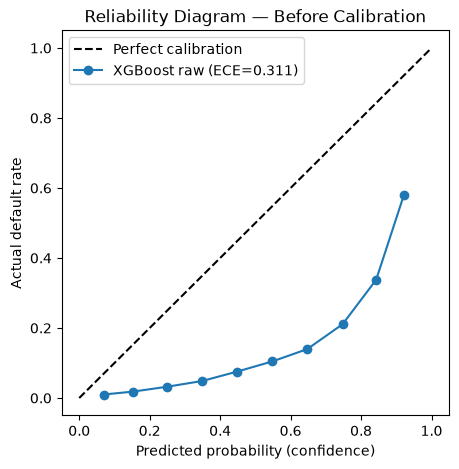

In [3]:
def compute_ece(y_true, y_prob, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    rows = []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (y_prob >= lo) & (y_prob < hi) if i < n_bins - 1 else (y_prob >= lo) & (y_prob <= hi)
        n = mask.sum()
        if n == 0:
            continue
        bin_conf = y_prob[mask].mean()
        bin_acc  = y_true[mask].mean()
        weight   = n / len(y_prob)
        ece += weight * abs(bin_acc - bin_conf)
        rows.append({'bin': f'{lo:.1f}-{hi:.1f}', 'n': n, 'confidence': bin_conf, 'actual_rate': bin_acc})
    return ece, pd.DataFrame(rows)

ece_raw, bins_raw = compute_ece(y_eval, prob_raw_eval)
print(f"보정 전 ECE: {ece_raw:.4f}")
print(bins_raw.to_string(index=False))

plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.plot(bins_raw['confidence'], bins_raw['actual_rate'], marker='o',
         label=f'XGBoost raw (ECE={ece_raw:.3f})')
plt.xlabel('Predicted probability (confidence)')
plt.ylabel('Actual default rate')
plt.title('Reliability Diagram — Before Calibration')
plt.legend()
plt.show()


**해석 (실행 후 위 ECE·표 값 기준으로 교체)**

> TODO: 위 ECE 값이 참고 기준(업계에서는 통상 0.05~0.10 이하를 양호로 봄) 대비 어느 수준인지, 어느 확률 구간에서 과대/과소 추정이 가장 큰지 bin 표를 근거로 서술.

**해석**

보정 전 ECE는 0.3112로, 낮은 편이라고 보기 어렵습니다. 또한 bin별 결과를 보면 모든 구간에서 예측 확률이 실제 부도율보다 높게 나타나, 모델이 전 구간에 걸쳐 부도 확률을 구조적으로 과대 추정하고 있음을 확인할 수 있습니다.

과대 추정 폭은 confidence가 높아질수록 커지다가 최상단에서 다시 완화되는 비선형 패턴을 보입니다. 예를 들어 0.0-0.1 구간은 confidence 0.069 대비 actual rate 0.010으로 격차가 0.06 수준이지만, 0.7-0.8 구간에서는 0.748 대비 0.211로 격차가 0.537까지 확대되어 전체 구간 중 가장 큽니다.즉, 모델은 고위험으로 분류한 일부 구간에서 실제 위험도를 일관되게 높게 추정하고 있으며, 특히 0.9-1.0 구간은 표본이 195건으로 제한적이므로 해석에 주의가 필요합니다.

이 패턴은 보정 전 확률이 전 구간에서 실제 부도율을 체계적으로 상회하고 있음을 보여줍니다. 이 상태로 EL에 그대로 대입하면 중~고위험 구간의 기대손실이 실제보다 과대 추정될 수 있으므로, 원시 확률에 대한 calibration이 필요합니다.

## Step 4. Platt Scaling vs Isotonic Regression

`Platt Scaling`과 `Isotonic Regression`을 동일한 `calib_fit`에 적합한 뒤, 학습에 사용되지 않은 `calib_eval`에서 보정 성능을 비교합니다.

- **Platt Scaling**: 원시 확률에 로지스틱 회귀를 적합하는 방식으로, 파라미터 수가 적어 표본이 적어도 비교적 안정적입니다. 다만 실제 miscalibration이 S자 형태를 크게 벗어나는 경우에는 표현력이 제한될 수 있습니다.
- **Isotonic Regression**: Isotonic Regression은 단조 증가 제약만 있는 비모수 방식으로 표현력은 높지만, 구간별 표본 수가 적으면 검증 데이터의 노이즈를 그대로 따라가 과적합할 수 있습니다. `calib_fit`이 `val_raw`의 절반이고 부도 표본도 희소하므로, 이 데이터셋에서는 Isotonic이 불안정해질 가능성을 염두에 두고 비교합니다.

두 방식 모두 단조 변환이므로 원시 확률의 순위 구조는 크게 유지되어야 합니다. 따라서 보정 전후 AUC와 KS가 유지되는지도 함께 확인합니다.


                 방식    ECE    AUC     KS
         Raw (보정 전) 0.3112 0.7646 0.3947
      Platt Scaling 0.0064 0.7646 0.3947
Isotonic Regression 0.0032 0.7640 0.3905


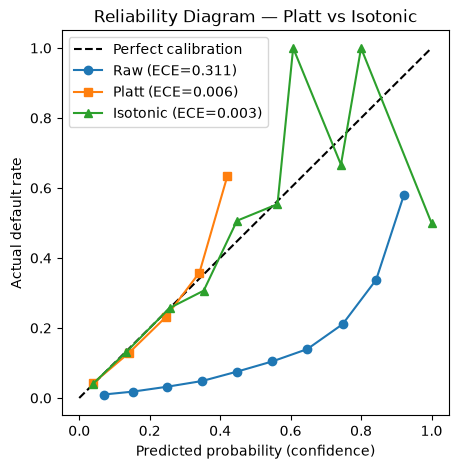

In [4]:
platt = LogisticRegression()
platt.fit(prob_raw_fit.reshape(-1, 1), y_fit)

iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(prob_raw_fit, y_fit)

prob_platt_eval = platt.predict_proba(prob_raw_eval.reshape(-1, 1))[:, 1]
prob_iso_eval   = iso.predict(prob_raw_eval)

ece_platt, bins_platt = compute_ece(y_eval, prob_platt_eval)
ece_iso, bins_iso     = compute_ece(y_eval, prob_iso_eval)

auc_raw    = roc_auc_score(y_eval, prob_raw_eval)
auc_platt  = roc_auc_score(y_eval, prob_platt_eval)
auc_iso    = roc_auc_score(y_eval, prob_iso_eval)

ks_raw,   _ = ks_2samp(prob_raw_eval[y_eval == 1],   prob_raw_eval[y_eval == 0])
ks_platt, _ = ks_2samp(prob_platt_eval[y_eval == 1], prob_platt_eval[y_eval == 0])
ks_iso,   _ = ks_2samp(prob_iso_eval[y_eval == 1],   prob_iso_eval[y_eval == 0])

summary = pd.DataFrame([
    {'방식': 'Raw (보정 전)', 'ECE': ece_raw,   'AUC': auc_raw,   'KS': ks_raw},
    {'방식': 'Platt Scaling',  'ECE': ece_platt, 'AUC': auc_platt, 'KS': ks_platt},
    {'방식': 'Isotonic Regression', 'ECE': ece_iso, 'AUC': auc_iso, 'KS': ks_iso},
]).round(4)
print(summary.to_string(index=False))

plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.plot(bins_raw['confidence'],   bins_raw['actual_rate'],   marker='o', label=f'Raw (ECE={ece_raw:.3f})')
plt.plot(bins_platt['confidence'], bins_platt['actual_rate'], marker='s', label=f'Platt (ECE={ece_platt:.3f})')
plt.plot(bins_iso['confidence'],   bins_iso['actual_rate'],   marker='^', label=f'Isotonic (ECE={ece_iso:.3f})')
plt.xlabel('Predicted probability (confidence)')
plt.ylabel('Actual default rate')
plt.title('Reliability Diagram — Platt vs Isotonic')
plt.legend()
plt.show()


**해석**

Isotonic은 ECE 0.0032로 Platt(0.0064)보다 낮아 전반적 보정 성능은 우수했지만, reliability diagram에서는 confidence 0.4~0.8 구간의 실제 부도율이 크게 요동치는 비단조 패턴이 관찰되었습니다. 이는 해당 구간의 `calib_fit` 표본, 특히 부도 건수가 적어 개별 케이스의 우연한 부도 여부가 예측 확률에 크게 반영된 결과로 해석됩니다. 따라서 ECE가 낮게 나온 것은 이런 불안정한 구간들이 전체 평균에서 상쇄된 결과일 수 있으며, 보정 성능이 구간별로 안정적이라고 보기는 어렵습니다.

AUC와 KS에서도 같은 경향이 확인됐습니다. Platt는 AUC 0.7646, KS 0.3947로 Raw와 거의 동일해 순위 구조를 유지했습니다. 반면 Isotonic은 AUC 0.7640, KS 0.3905로 소폭 하락했는데, 이는 구간별 값을 평평하게 묶는 특성 때문에 일부 구간에서 분리력이 약간 줄어든 결과로 해석할 수 있습니다.

종합하면 Isotonic은 집계 지표(ECE)에서는 우세해 보이지만, 곡선의 안정성과 순위 보존 측면에서는 Platt보다 상대적으로 불리합니다. 표본이 제한적인 본 데이터셋에서는 안정성을 우선하여 Platt Scaling을 최종 방법으로 채택합니다.

## Step 5. 최종 선정

위 비교를 근거로 **Platt Scaling**을 최종 calibration 방식으로 채택합니다. 판단 기준은 두 가지입니다.

1. **표본 안정성**: 표본 안정성 측면에서, `calib_fit`의 부도 건수가 제한적이기 때문에 비모수 방식인 Isotonic보다 적은 수의 파라미터로 적합하는 Platt Scaling이 노이즈에 덜 민감합니다. 실제로 Isotonic의 reliability diagram은 confidence 중상위 구간에서 비단조적으로 흔들린 반면, Platt는 상대적으로 매끈한 보정 곡선을 유지했습니다.
2. **순위 보존**: Platt는 원시 점수에 단조 증가하는 로지스틱 함수를 적용하므로 AUC와 KS를 거의 그대로 유지했습니다. 실제로 AUC 0.7646, KS 0.3947로 Raw와 사실상 동일했습니다. 반면 Isotonic은 tie가 생기면서 AUC 0.7640, KS 0.3905로 미세한 순위 손실이 관찰됐습니다.

## Step 6. 최종 Calibrator 적합 및 저장

방식이 정해졌으므로, 실제 배포와 정책 설계에 사용할 최종 calibrator는 `val_raw` 전체로 다시 적합해 가용 데이터를 최대한 활용합니다. 앞선 held-out 분리는 방식 선택과 평가를 위한 것이었고, 최종 산출물은 `val_raw` 기준으로 저장합니다.

저장하는 산출물은 다음과 같습니다.

- `xgb_final_model.pkl`, `xgb_ordinal_encoder.pkl` — 03에서 저장하지 않았던 최종 모델·인코더 (05, 06에서 재사용)
- `platt_calibrator.pkl` — 최종 calibration 모델
- `val_scored.csv` — `PD_raw`, `PD_calibrated`가 포함된 검증셋 (05_policy_simulation.ipynb의 입력)


In [5]:
import os
import joblib

platt_final = LogisticRegression()
platt_final.fit(val_prob_raw.reshape(-1, 1), val_raw['TARGET'].values)

val_prob_calibrated = platt_final.predict_proba(val_prob_raw.reshape(-1, 1))[:, 1]

final_ece_raw, _        = compute_ece(val_raw['TARGET'].values, val_prob_raw)
final_ece_calibrated, _ = compute_ece(val_raw['TARGET'].values, val_prob_calibrated)
final_auc_calibrated    = roc_auc_score(val_raw['TARGET'], val_prob_calibrated)

print(f"전체 val_raw 기준 ECE: {final_ece_raw:.4f} → {final_ece_calibrated:.4f}")
print(f"전체 val_raw 기준 AUC: {reproduced_auc:.4f} → {final_auc_calibrated:.4f} (순위 보존 확인)")

os.makedirs('../models', exist_ok=True)
joblib.dump(xgb_model, '../models/xgb_final_model.pkl')
joblib.dump(oe,        '../models/xgb_ordinal_encoder.pkl')
joblib.dump(platt_final, '../models/platt_calibrator.pkl')

id_col = 'SK_ID_CURR' if 'SK_ID_CURR' in val_raw.columns else val_raw.columns[0]
val_scored = val_raw[[id_col, 'TARGET']].copy()
val_scored['PD_raw'] = val_prob_raw
val_scored['PD_calibrated'] = val_prob_calibrated
val_scored.to_csv('../data/val_scored.csv', index=False)

print(f"\n저장 완료: ../models/xgb_final_model.pkl, xgb_ordinal_encoder.pkl, platt_calibrator.pkl")
print(f"저장 완료: ../data/val_scored.csv ({len(val_scored):,}행)")


전체 val_raw 기준 ECE: 0.3113 → 0.0061
전체 val_raw 기준 AUC: 0.7689 → 0.7689 (순위 보존 확인)

저장 완료: ../models/xgb_final_model.pkl, xgb_ordinal_encoder.pkl, platt_calibrator.pkl
저장 완료: ../data/val_scored.csv (61,503행)


## 다음 단계에서는

이 노트북에서 확정한 것은 다음과 같습니다.

- **최종 calibration 방식**: Platt Scaling (Isotonic 대비 표본 안정성 우선, AUC/KS 순위 보존 확인)
- **산출물**: `PD_calibrated` — 실제 부도율에 맞춰 보정된 확률값
- **원칙**: calibration 평가는 모델 선택에 쓰인 `val_raw`와 분리된 held-out(`calib_eval`)에서 수행해 이중 사용을 피함

다음 `05_policy_simulation.ipynb`에서는 이 `PD_calibrated`를 `00_lgd_estimation.ipynb`에서 확정한 LGD(0.40 / 0.55 / 0.75 시나리오)와 결합해 `EL = PD × LGD × EAD`를 계산하고, PD 구간별 한도 정책 매트릭스와 시나리오별 손익을 시뮬레이션합니다.